In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset, treating '?' as NaN
df = pd.read_csv('D:/MLE/Assignment_4/auto-mpg.csv', na_values='?')

# Display first 10 rows
print("First 10 rows:")
print(df.head(10))

# Dataset shape
print("\nDataset shape:", df.shape)

# Column names
print("\nColumn names:", df.columns.tolist())


First 10 rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   
5  15.0          8         429.0       198.0    4341          10.0   
6  14.0          8         454.0       220.0    4354           9.0   
7  14.0          8         440.0       215.0    4312           8.5   
8  14.0          8         455.0       225.0    4425          10.0   
9  15.0          8         390.0       190.0    3850           8.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3         

In [2]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Handle missing values: Use median for horsepower (robust to outliers), no missing in mpg
horsepower_median = df['horsepower'].median()
df['horsepower'].fillna(horsepower_median, inplace=True)
df.dropna(subset=['mpg'], inplace=True)  # No mpg missing, but for completeness

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"\nMethod used: Median imputation for horsepower ({horsepower_median}). No action needed for mpg.")


Missing values before cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Missing values after cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Method used: Median imputation for horsepower (93.5). No action needed for mpg.


In [3]:
# Select features
features = ['cylinders', 'horsepower', 'weight', 'displacement']
X = df[features]
y = df['mpg']
print("Selected features:", features)


Selected features: ['cylinders', 'horsepower', 'weight', 'displacement']


In [4]:
# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


Training set: (318, 4), Test set: (80, 4)


In [5]:
# Train linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Coefficients:", dict(zip(features, lr.coef_.round(4))))
print("Intercept:", lr.intercept_.round(4))


Coefficients: {'cylinders': np.float64(-0.1862), 'horsepower': np.float64(-0.0403), 'weight': np.float64(-0.0053), 'displacement': np.float64(-0.0056)}
Intercept: 45.6376


In [6]:
# Predictions
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


MAE: 3.1192
MSE: 14.6704
RMSE: 3.8302
R²: 0.7271


In [7]:
# Degrees 2 and 3
degrees = [2, 3]
train_scores = {}
test_scores = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    
    train_r2 = r2_score(y_train, poly_model.predict(X_train_poly))
    test_r2 = r2_score(y_test, poly_model.predict(X_test_poly))
    
    train_scores[degree] = train_r2
    test_scores[degree] = test_r2
    
    print(f"Degree {degree}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}")

# Linear for comparison
print(f"Degree 1: Train R²={r2_score(y_train, lr.predict(X_train)):.4f}, Test R²={r2:.4f}")


Degree 2: Train R²=0.7544, Test R²=0.7782
Degree 3: Train R²=0.7828, Test R²=0.7808
Degree 1: Train R²=0.6996, Test R²=0.7271


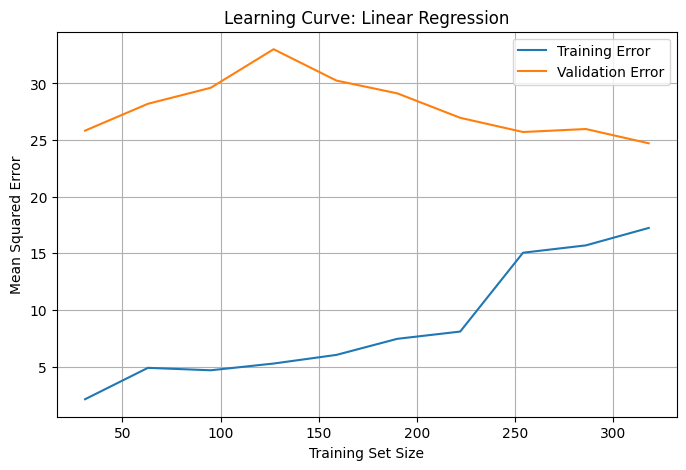

In [8]:
# Learning curve for linear regression
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    lr, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10), scoring='neg_mean_squared_error'
)

train_errors = -train_scores_lc.mean(axis=1)
val_errors = -val_scores_lc.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_errors, label='Training Error')
plt.plot(train_sizes, val_errors, label='Validation Error')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve: Linear Regression')
plt.legend()
plt.grid(True)
plt.show()


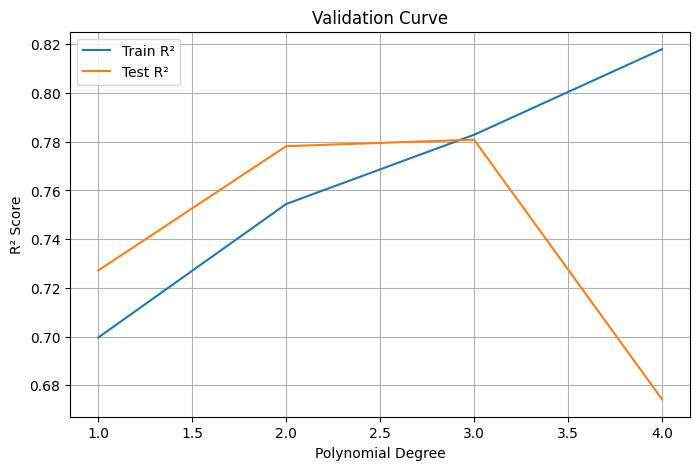

Best degree: 3 (Test R²=0.7808)


In [9]:
# Validation curve for polynomial degrees
degrees_range = np.arange(1, 5)
train_scores_vc, val_scores_vc = validation_curve(
    LinearRegression(), X, y, param_name='fit_intercept',  # Dummy; actually vary poly degree via pipeline
    param_range=degrees_range, cv=5, scoring='r2'
)

# Custom for poly degrees
r2_train = [r2_score(y_train, Pipeline([('poly', PolynomialFeatures(d)), ('lr', LinearRegression())]).fit(X_train, y_train).predict(X_train)) for d in degrees_range]
r2_val = [r2_score(y_test, Pipeline([('poly', PolynomialFeatures(d)), ('lr', LinearRegression())]).fit(X_train, y_train).predict(X_test)) for d in degrees_range]

plt.figure(figsize=(8, 5))
plt.plot(degrees_range, r2_train, label='Train R²')
plt.plot(degrees_range, r2_val, label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Validation Curve')
plt.legend()
plt.grid(True)
plt.show()

best_degree = degrees_range[np.argmax(r2_val)]
print(f"Best degree: {best_degree} (Test R²={max(r2_val):.4f})")
